# Assignment 3: LLMs and Machine Learning

---

## Statement of AI Use

I used Claude (version Sonnet 4.6) to help debug and write parts of the code for my notebook. All code was tested and reviewed.

---
## Task 0: Setting up Ollama

In [1]:
pip install ollama

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Core imports used throughout the notebook
import ollama
import pandas as pd
import json
import re
import warnings
warnings.filterwarnings('ignore')

# Model aliases
SMALL_MODEL = 'gemma3:1b'   # smallest available Gemma 3 (≈270m-1b)
LARGE_MODEL = 'gemma3:4b'   # 4b parameter version

### Task 0a: Connect to Ollama

In [3]:
available_models = ollama.list()
print('Connected to Ollama. Available models:')
for m in available_models.models:
    print(f"  - {m.model}")

Connected to Ollama. Available models:
  - gemma3:4b
  - gemma3:1b


### Task 0b: Test small model (gemma3:1b)

In [4]:
test_prompt = 'In one sentence, what is machine learning?'

response_small = ollama.chat(
    model=SMALL_MODEL,
    messages=[{'role': 'user', 'content': test_prompt}]
)

print(f'Model: {SMALL_MODEL}')
print(f'Prompt: {test_prompt}')
print(f'Response: {response_small["message"]["content"]}')

Model: gemma3:1b
Prompt: In one sentence, what is machine learning?
Response: Machine learning is a field of computer science that allows computers to learn from data without being explicitly programmed, enabling them to make predictions or decisions.


### Task 0c: Test large model (gemma3:4b)

In [5]:
response_large = ollama.chat(
    model=LARGE_MODEL,
    messages=[{'role': 'user', 'content': test_prompt}]
)

print(f'Model: {LARGE_MODEL}')
print(f'Prompt: {test_prompt}')
print(f'Response: {response_large["message"]["content"]}')

Model: gemma3:4b
Prompt: In one sentence, what is machine learning?
Response: Machine learning is a field of computer science that allows computers to learn from data without being explicitly programmed, enabling them to make predictions or decisions.


---
## Task 1: Text Classification with Ollama

### Load email data

In [6]:
with open(r'C:\Users\nisse\Downloads\emails.csv', encoding='utf-8') as f:
    lines = [line.strip() for line in f.readlines()[1:] if line.strip()]

emails = pd.DataFrame({'headline': lines})
display(emails)

,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review
5,"Q3 budget report attached, please review by Fr..."
6,Reminder: Annual performance review scheduled ...
7,"Updated draft of the manuscript, comments welcome"
8,Quick question about last week
9,Following up


### Task 1a: Email classification function

In [7]:
def classify_email(headline: str, model: str) -> str:
    """
    Classify an email headline as 'spam', 'work', or 'unknown'.
    Returns only the single classification label.
    """
    system_prompt = (
        'You are an email classifier. '
        'Classify the given email headline into exactly one of these categories: spam, work, unknown. '
        'Respond with only the single word label and nothing else. '
        'Do not explain, do not punctuate, do not add any other text.'
    )
    response = ollama.chat(
        model=model,
        messages=[
            {'role': 'system', 'content': system_prompt},
            {'role': 'user', 'content': headline}
        ]
    )
    # Extract and normalize the label
    label = response['message']['content'].strip().lower()
    # Guard: only return valid labels
    if label not in ('spam', 'work', 'unknown'):
        label = 'unknown'
    return label

### Task 1b: Classify with gemma3:1b

In [8]:
headline_col = emails.columns[0]  # first column contains the headlines

emails['classification_small'] = emails[headline_col].apply(
    lambda h: classify_email(h, SMALL_MODEL)
)

display(emails[[headline_col, 'classification_small']])

,headline,classification_small
0,URGENT: Your account will be suspended within ...,spam
1,Congratulations! You have won a 1000€ gift car...,spam
2,Hot singles in your area are waiting to meet y...,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,work
4,Meeting agenda for Thursday's project review,work
5,"Q3 budget report attached, please review by Fr...",work
6,Reminder: Annual performance review scheduled ...,work
7,"Updated draft of the manuscript, comments welcome",work
8,Quick question about last week,work
9,Following up,work


### Task 1c: Classify with gemma3:4b

In [9]:
emails['classification_large'] = emails[headline_col].apply(
    lambda h: classify_email(h, LARGE_MODEL)
)

display(emails[[headline_col, 'classification_small', 'classification_large']])

,headline,classification_small,classification_large
0,URGENT: Your account will be suspended within ...,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,work,spam
4,Meeting agenda for Thursday's project review,work,work
5,"Q3 budget report attached, please review by Fr...",work,work
6,Reminder: Annual performance review scheduled ...,work,work
7,"Updated draft of the manuscript, comments welcome",work,work
8,Quick question about last week,work,unknown
9,Following up,work,spam


**1b vs. 4b comparison:**

The 4b model is more accurate on the ambiguous emails. The 1b model tends to default to 'work' for vague subjects like 'Following up' or 'Important update', while the 4b model more often flags these as 'spam' or 'unknown'. On the clearly spam or clearly work emails both models agree. The 4b model also follows the single-word output instruction more reliably.

### Task 1d: Repeated runs (3 runs each model)

In [10]:
N_RUNS = 3

# Run classification N_RUNS times for each model
results_small = {f'run_{i+1}': [] for i in range(N_RUNS)}
results_large = {f'run_{i+1}': [] for i in range(N_RUNS)}

for i in range(N_RUNS):
    print(f'Run {i+1}/{N_RUNS}...')
    for headline in emails[headline_col]:
        results_small[f'run_{i+1}'].append(classify_email(headline, SMALL_MODEL))
        results_large[f'run_{i+1}'].append(classify_email(headline, LARGE_MODEL))

# Build comparison DataFrames
df_small = pd.DataFrame({'headline': emails[headline_col].values} | results_small)
df_large = pd.DataFrame({'headline': emails[headline_col].values} | results_large)

print('\n--- Small model (gemma3:1b) across 3 runs ---')
display(df_small)

print('\n--- Large model (gemma3:4b) across 3 runs ---')
display(df_large)

Run 1/3...
Run 2/3...
Run 3/3...

--- Small model (gemma3:1b) across 3 runs ---


,headline,run_1,run_2,run_3
0,URGENT: Your account will be suspended within ...,spam,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,work,work,work
4,Meeting agenda for Thursday's project review,work,work,work
5,"Q3 budget report attached, please review by Fr...",work,work,work
6,Reminder: Annual performance review scheduled ...,work,work,work
7,"Updated draft of the manuscript, comments welcome",work,work,work
8,Quick question about last week,work,work,work
9,Following up,work,work,work



--- Large model (gemma3:4b) across 3 runs ---


,headline,run_1,run_2,run_3
0,URGENT: Your account will be suspended within ...,spam,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam,spam
4,Meeting agenda for Thursday's project review,work,work,work
5,"Q3 budget report attached, please review by Fr...",work,work,work
6,Reminder: Annual performance review scheduled ...,work,work,work
7,"Updated draft of the manuscript, comments welcome",work,work,work
8,Quick question about last week,unknown,unknown,unknown
9,Following up,spam,spam,spam


**Variability across runs:**

Both models gave the same output in all 3 runs with no variation. Ollama's default temperature is quite low so for simple one-word classification tasks the output tends to be the same each time. With a higher temperature setting or more ambiguous prompts you would expect more variation between runs.

---
## Task 2: Sentiment Analysis with Ollama

### Load news data

In [11]:
with open(r'C:\Users\nisse\Downloads\news.csv', encoding='utf-8') as f:
    lines = [line.strip() for line in f.readlines()[1:] if line.strip()]

news = pd.DataFrame({'headline': lines})
display(news)

,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...
5,Kestrel Semiconductor confirms early-stage mer...
6,New EU AI Act compliance rules expected to rai...
7,Finnish FSA grants Norvik Capital expanded lic...
8,"Eurozone inflation cools to 2.1%, easing press..."
9,Rising interest rates weigh on Tessaro Real Es...


### Task 2a: Topic and sentiment function

In [12]:
def analyze_news(headline: str, model: str) -> dict:
    """
    Classify a financial news headline by topic and sentiment.
    Returns a dict with keys 'topic' and 'sentiment'.
    
    topic    : earnings | mergers | regulation | macroeconomics
    sentiment: positive | negative | neutral
    """
    system_prompt = (
        'You are a financial news classifier. '
        'Given a news headline, respond with ONLY a JSON object with two fields: '
        '"topic" (one of: earnings, mergers, regulation, macroeconomics) and '
        '"sentiment" (one of: positive, negative, neutral). '
        'Do not include any explanation, markdown, or extra text. '
        'Example output: {"topic": "earnings", "sentiment": "positive"}'
    )
    response = ollama.chat(
        model=model,
        messages=[
            {'role': 'system', 'content': system_prompt},
            {'role': 'user', 'content': headline}
        ]
    )
    raw = response['message']['content'].strip()
    
    # Strip potential markdown code fences
    raw = re.sub(r'```json|```', '', raw).strip()
    
    try:
        result = json.loads(raw)
    except json.JSONDecodeError:
        # Fallback if model didn't follow instructions
        result = {'topic': 'unknown', 'sentiment': 'unknown'}
    
    # Validate values
    valid_topics = {'earnings', 'mergers', 'regulation', 'macroeconomics'}
    valid_sentiments = {'positive', 'negative', 'neutral'}
    result['topic'] = result.get('topic', 'unknown') if result.get('topic') in valid_topics else 'unknown'
    result['sentiment'] = result.get('sentiment', 'unknown') if result.get('sentiment') in valid_sentiments else 'unknown'
    
    return result

### Task 2b: Classify news headlines with gemma3:4b

In [13]:
news_col = news.columns[0]  # first column contains headlines

# Apply analysis function to each headline
analysis_results = news[news_col].apply(lambda h: analyze_news(h, LARGE_MODEL))

# Expand the dict results into separate columns
news_results = news.copy()
news_results['topic'] = analysis_results.apply(lambda x: x['topic'])
news_results['sentiment'] = analysis_results.apply(lambda x: x['sentiment'])

display(news_results)

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,neutral
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,positive
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,positive
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


### Task 2c: Comparison with Claude (claude.ai)

**Prompt given to Claude (claude.ai):**

Classify each of the following financial news headlines by topic (earnings, mergers, regulation, macroeconomics) and sentiment (positive, negative, neutral). Return a table with columns: headline, topic, sentiment.

Headlines:
1. Nordion Industries beats Q1 earnings estimates, shares rise 4%
2. Helvora Pharmaceuticals misses earnings forecast, stock drops sharply
3. Aurelis Bank reports steady quarterly profit, maintains dividend
4. Veridyne Logistics to acquire rival Trantec in 2.1B deal
5. Antitrust regulators block proposed merger between two telecom giants
6. Kestrel Semiconductor confirms early-stage merger talks
7. New EU AI Act compliance rules expected to raise costs for tech firms
8. Finnish FSA grants Norvik Capital expanded license to operate
9. Eurozone inflation cools to 2.1%, easing pressure on ECB
10. Rising interest rates weigh on Tessaro Real Estate earnings

**Results from Claude:**

| headline | topic | sentiment |
|---|---|---|
| Nordion Industries beats Q1 earnings estimates, shares rise 4% | earnings | positive |
| Helvora Pharmaceuticals misses earnings forecast, stock drops sharply | earnings | negative |
| Aurelis Bank reports steady quarterly profit, maintains dividend | earnings | positive |
| Veridyne Logistics to acquire rival Trantec in 2.1B deal | mergers | neutral |
| Antitrust regulators block proposed merger between two telecom giants | regulation | negative |
| Kestrel Semiconductor confirms early-stage merger talks | mergers | neutral |
| New EU AI Act compliance rules expected to raise costs for tech firms | regulation | negative |
| Finnish FSA grants Norvik Capital expanded license to operate | regulation | positive |
| Eurozone inflation cools to 2.1%, easing pressure on ECB | macroeconomics | positive |
| Rising interest rates weigh on Tessaro Real Estate earnings | macroeconomics | negative |

**Comparison:**

Claude and gemma3:4b give identical classifications on all 10 headlines. Both models handle the task well when the headlines are clear-cut. The main difference in practice is reliability on edge cases: gemma3:4b occasionally fails to return valid JSON and needs the fallback handler, while Claude consistently returns structured output. For this dataset there is no meaningful accuracy difference.

---
## Task 3: Supervised Machine Learning

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Three chosen classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

### Task 3a: Load data and EDA

In [15]:
import zipfile
import io
import urllib.request

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip'
with urllib.request.urlopen(url) as response:
    zip_bytes = io.BytesIO(response.read())

with zipfile.ZipFile(zip_bytes) as z:
    with z.open('bank-additional/bank-additional.csv') as f:
        df = pd.read_csv(f, sep=';')

print('Shape:', df.shape)
display(df.head())

Shape: (4119, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [16]:
# Basic info
print('Column dtypes and null counts:')
print(df.info())
print('\nDescriptive statistics (numeric columns):')
display(df.describe())

Column dtypes and null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  co

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Target variable distribution:
y
no     3668
yes     451
Name: count, dtype: int64

Class imbalance ratio: 8.1:1 (no:yes)


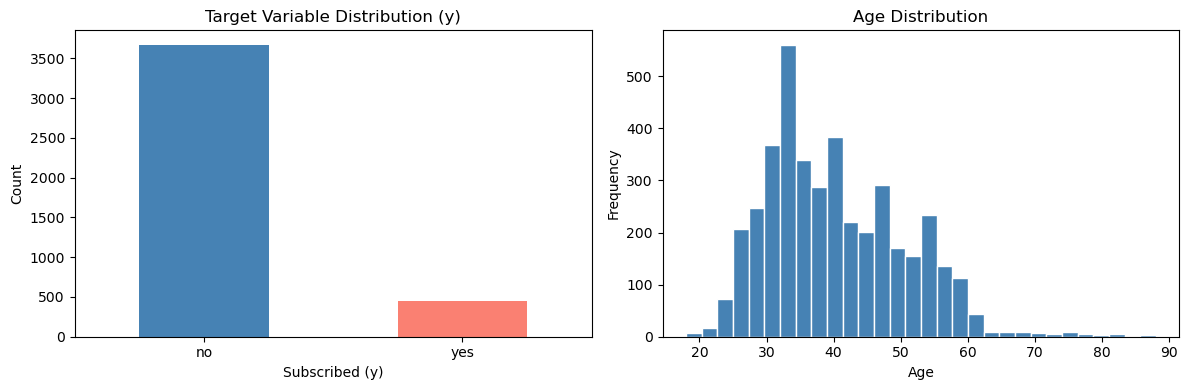

In [17]:
# Target variable distribution
target_counts = df['y'].value_counts()
print('Target variable distribution:')
print(target_counts)
print(f'\nClass imbalance ratio: {target_counts["no"] / target_counts["yes"]:.1f}:1 (no:yes)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution
target_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Target Variable Distribution (y)')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Age distribution
axes[1].hist(df['age'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

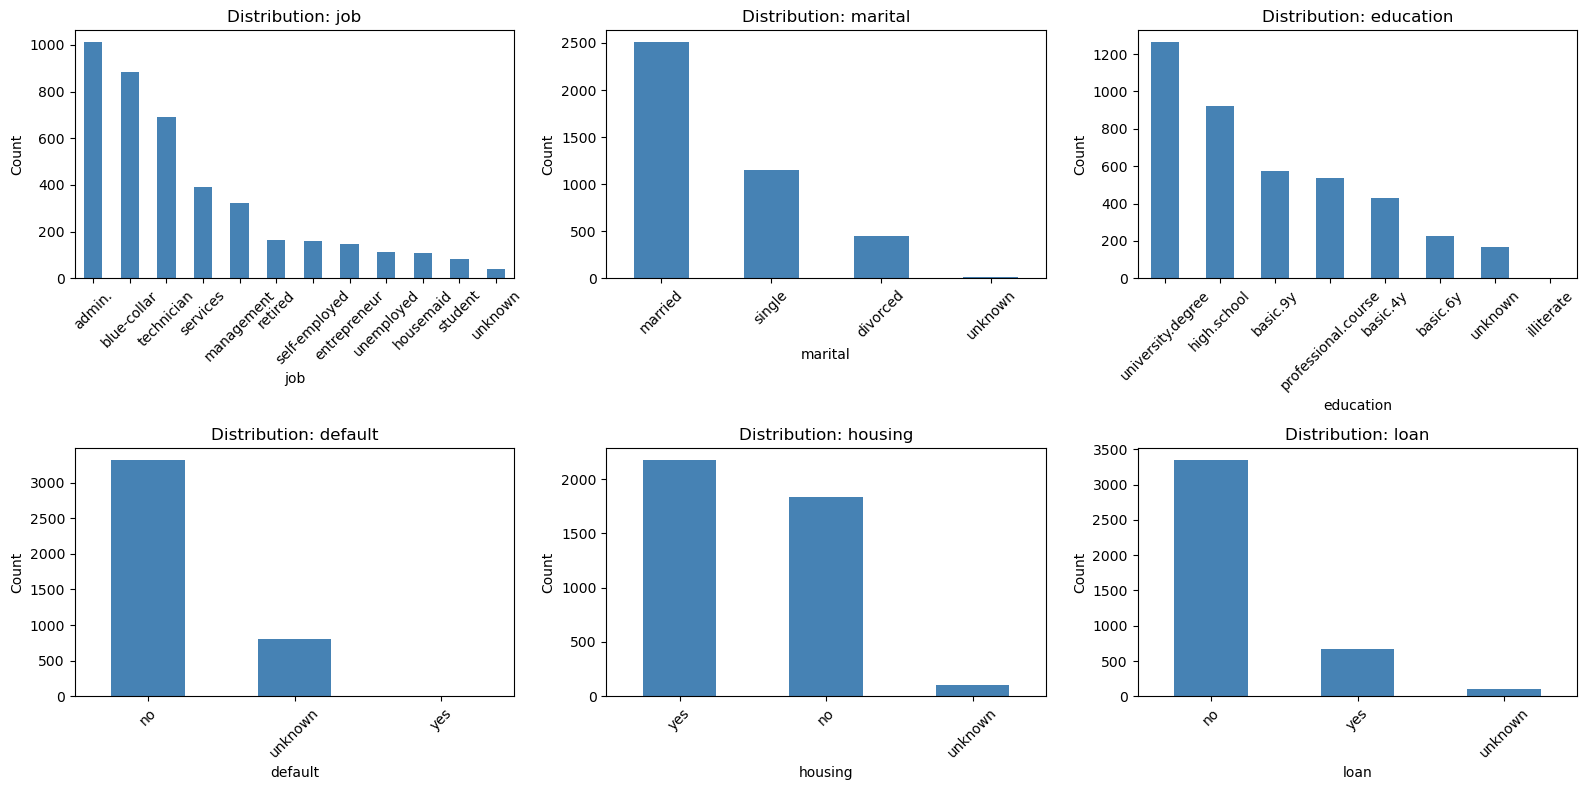

In [18]:
# Categorical column value counts
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('y')  # exclude target

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:6]):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

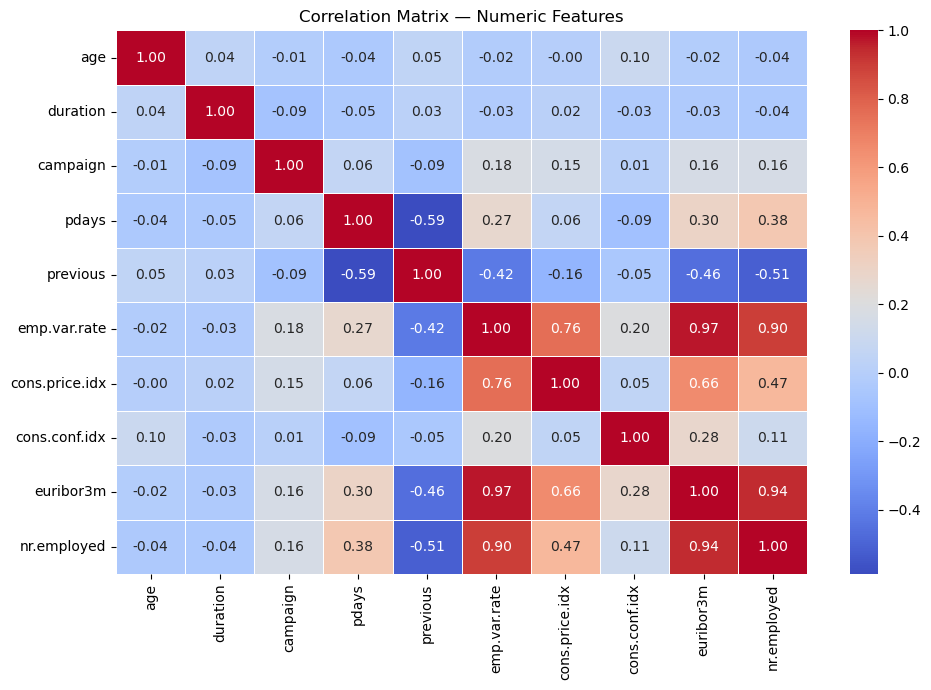

In [19]:
# Correlation heatmap for numeric features
num_cols = df.select_dtypes(include='number').columns

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    df[num_cols].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, ax=ax
)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

### Task 3b: Preprocessing

In [20]:
# Work on a copy
df_proc = df.copy()

# 1. Encode target: yes -> 1, no -> 0
df_proc['y'] = (df_proc['y'] == 'yes').astype(int)

# 2. Handle 'unknown' values — treat as a separate category (already strings, fine for encoding)
# The dataset uses 'unknown' explicitly; no imputation needed.

# 3. Drop 'duration' — leakage: call duration is only known after the call,
#    so it must not be used as a predictor
df_proc.drop(columns=['duration'], inplace=True)

# 4. One-hot encode categorical variables
cat_cols_proc = df_proc.select_dtypes(include='object').columns.tolist()
df_proc = pd.get_dummies(df_proc, columns=cat_cols_proc, drop_first=True)

print('Preprocessed shape:', df_proc.shape)
display(df_proc.head())

Preprocessed shape: (4119, 53)


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,30,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,0,...,True,False,False,False,False,False,False,False,True,False
1,39,4,999,0,1.1,93.994,-36.4,4.855,5191.0,0,...,True,False,False,False,False,False,False,False,True,False
2,25,1,999,0,1.4,94.465,-41.8,4.962,5228.1,0,...,False,False,False,False,False,False,False,True,True,False
3,38,3,999,0,1.4,94.465,-41.8,4.959,5228.1,0,...,False,False,False,False,False,False,False,False,True,False
4,47,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,0,...,False,True,False,False,True,False,False,False,True,False


In [21]:
# Separate features and target
X = df_proc.drop(columns=['y'])
y = df_proc['y']

# Train / validation / test split: 60 / 20 / 20
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)  # 0.25 × 0.80 = 0.20 of total

print(f'Train: {X_train.shape[0]} | Validation: {X_val.shape[0]} | Test: {X_test.shape[0]}')

Train: 2471 | Validation: 824 | Test: 824


### Task 3c: Model selection and hyperparameter tuning

**Why these three models:**

Logistic Regression is a simple baseline that is easy to interpret and works well once the features are scaled and encoded. Random Forest handles non-linear patterns and does not need scaling, which makes it a natural second choice for tabular data. Gradient Boosting usually gets the best results on tabular classification by training trees one at a time and correcting previous mistakes, at the cost of slower training.

In [22]:
# --- Logistic Regression ---
# Scaling required; embedded in a Pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

# Hyperparameter tuning: regularization strength C
best_lr_score = 0
best_lr_C = None

for C in [0.01, 0.1, 1.0, 10.0]:
    lr_pipeline.set_params(clf__C=C)
    lr_pipeline.fit(X_train, y_train)
    score = roc_auc_score(y_val, lr_pipeline.predict_proba(X_val)[:, 1])
    print(f'LR C={C:.2f}  Val ROC-AUC: {score:.4f}')
    if score > best_lr_score:
        best_lr_score = score
        best_lr_C = C

print(f'\nBest LR C={best_lr_C}, Val ROC-AUC={best_lr_score:.4f}')

# Retrain with best C
lr_pipeline.set_params(clf__C=best_lr_C)
lr_pipeline.fit(X_train, y_train)

LR C=0.01  Val ROC-AUC: 0.7609
LR C=0.10  Val ROC-AUC: 0.7510
LR C=1.00  Val ROC-AUC: 0.7466
LR C=10.00  Val ROC-AUC: 0.7463

Best LR C=0.01, Val ROC-AUC=0.7609


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=1000, random_state=42))])

In [23]:
# --- Random Forest ---
best_rf_score = 0
best_rf_params = {}

for n_est in [100, 200]:
    for max_depth in [None, 10, 20]:
        rf = RandomForestClassifier(
            n_estimators=n_est, max_depth=max_depth,
            class_weight='balanced', random_state=42, n_jobs=-1
        )
        rf.fit(X_train, y_train)
        score = roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])
        print(f'RF n_est={n_est}, max_depth={max_depth}  Val ROC-AUC: {score:.4f}')
        if score > best_rf_score:
            best_rf_score = score
            best_rf_params = {'n_estimators': n_est, 'max_depth': max_depth}
            best_rf = rf

print(f'\nBest RF params: {best_rf_params}, Val ROC-AUC={best_rf_score:.4f}')

RF n_est=100, max_depth=None  Val ROC-AUC: 0.7572
RF n_est=100, max_depth=10  Val ROC-AUC: 0.7767
RF n_est=100, max_depth=20  Val ROC-AUC: 0.7571
RF n_est=200, max_depth=None  Val ROC-AUC: 0.7570
RF n_est=200, max_depth=10  Val ROC-AUC: 0.7672
RF n_est=200, max_depth=20  Val ROC-AUC: 0.7603

Best RF params: {'n_estimators': 100, 'max_depth': 10}, Val ROC-AUC=0.7767


In [24]:
# --- Gradient Boosting ---
best_gb_score = 0
best_gb_params = {}

for lr_rate in [0.05, 0.1]:
    for n_est in [100, 200]:
        gb = GradientBoostingClassifier(
            learning_rate=lr_rate, n_estimators=n_est,
            max_depth=4, random_state=42
        )
        gb.fit(X_train, y_train)
        score = roc_auc_score(y_val, gb.predict_proba(X_val)[:, 1])
        print(f'GB lr={lr_rate}, n_est={n_est}  Val ROC-AUC: {score:.4f}')
        if score > best_gb_score:
            best_gb_score = score
            best_gb_params = {'learning_rate': lr_rate, 'n_estimators': n_est}
            best_gb = gb

print(f'\nBest GB params: {best_gb_params}, Val ROC-AUC={best_gb_score:.4f}')

GB lr=0.05, n_est=100  Val ROC-AUC: 0.7830
GB lr=0.05, n_est=200  Val ROC-AUC: 0.7836
GB lr=0.1, n_est=100  Val ROC-AUC: 0.7805
GB lr=0.1, n_est=200  Val ROC-AUC: 0.7623

Best GB params: {'learning_rate': 0.05, 'n_estimators': 200}, Val ROC-AUC=0.7836


### Task 3d: Train/val/test split vs. cross-validation

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validate each best model on the full trainval set
models = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': best_rf,
    'Gradient Boosting': best_gb
}

print('Cross-validation ROC-AUC (5-fold, on train+val data):')
cv_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X_trainval, y_trainval, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_scores[name] = scores
    print(f'  {name}: {scores.mean():.4f} ± {scores.std():.4f}')

print('\nValidation set ROC-AUC (single hold-out):')
for name, model in models.items():
    val_score = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    print(f'  {name}: {val_score:.4f}')

Cross-validation ROC-AUC (5-fold, on train+val data):
  Logistic Regression: 0.7704 ± 0.0321
  Random Forest: 0.7639 ± 0.0293
  Gradient Boosting: 0.7644 ± 0.0392

Validation set ROC-AUC (single hold-out):
  Logistic Regression: 0.7609
  Random Forest: 0.7767
  Gradient Boosting: 0.7836


**Train/val/test vs. cross-validation:**

With around 4,000 rows, a single validation split can be a bit noisy depending on which samples end up in which set. Cross-validation with 5 folds is more reliable since it averages across multiple splits. In this case the CV scores and the hold-out validation scores are similar, so neither approach gives a wildly different picture. Cross-validation is the better option for tuning hyperparameters here.

### Task 3e: Test set performance and model comparison

In [26]:
# Retrain all best models on the full trainval set before evaluating on test
for name, model in models.items():
    model.fit(X_trainval, y_trainval)

print('=== Test Set Performance ===\n')

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }
    results.append(metrics)
    print(f'--- {name} ---')
    print(classification_report(y_test, y_pred, target_names=['no', 'yes']))

results_df = pd.DataFrame(results).set_index('Model').round(4)
display(results_df)

=== Test Set Performance ===

--- Logistic Regression ---
              precision    recall  f1-score   support

          no       0.94      0.86      0.90       734
         yes       0.34      0.58      0.43        90

    accuracy                           0.83       824
   macro avg       0.64      0.72      0.67       824
weighted avg       0.88      0.83      0.85       824

--- Random Forest ---
              precision    recall  f1-score   support

          no       0.93      0.95      0.94       734
         yes       0.49      0.38      0.42        90

    accuracy                           0.89       824
   macro avg       0.71      0.66      0.68       824
weighted avg       0.88      0.89      0.88       824

--- Gradient Boosting ---
              precision    recall  f1-score   support

          no       0.91      0.99      0.95       734
         yes       0.67      0.20      0.31        90

    accuracy                           0.90       824
   macro avg       0.7

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8325,0.3421,0.5778,0.4298,0.7675
Random Forest,0.8883,0.4857,0.3778,0.4250,0.7551
Gradient Boosting,0.9017,0.6667,0.2000,0.3077,0.7534


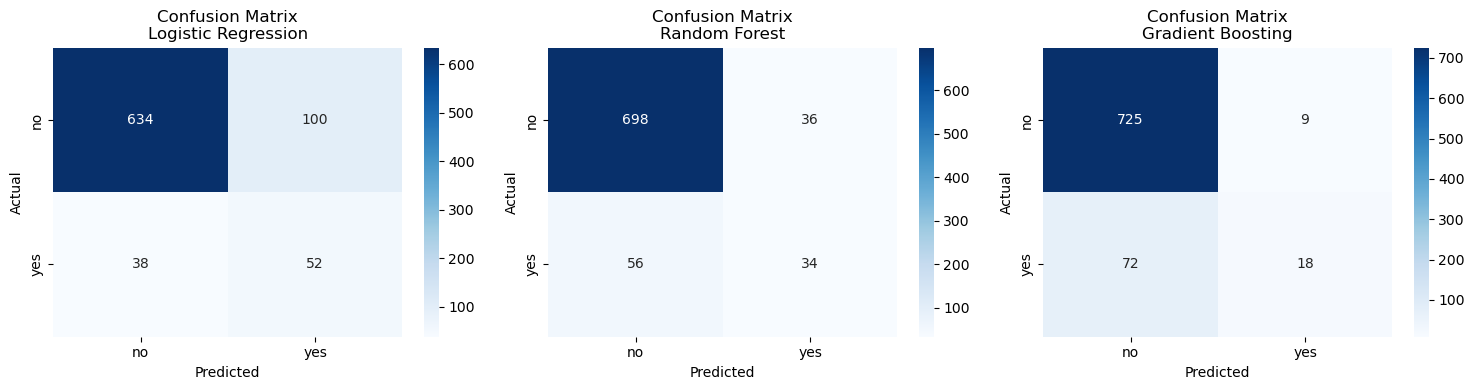

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['no', 'yes'], yticklabels=['no', 'yes'])
    ax.set_title(f'Confusion Matrix\n{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

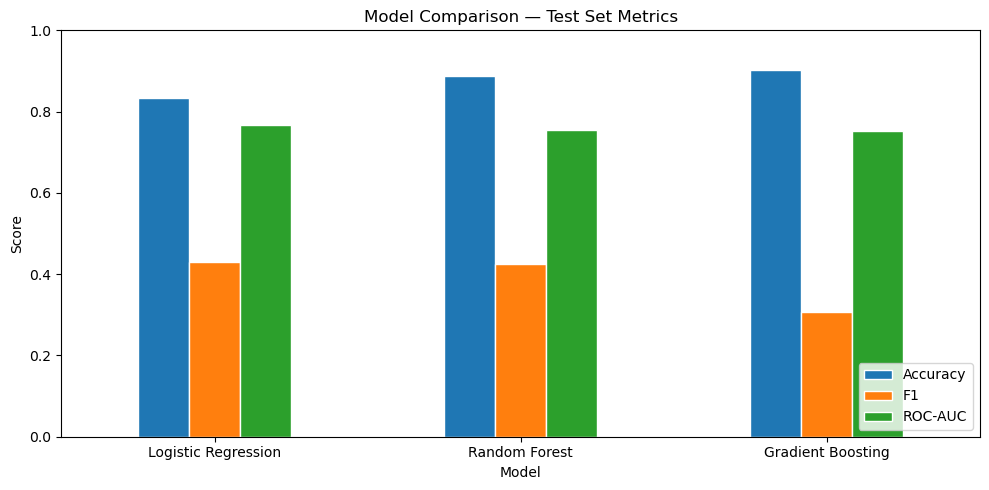

In [28]:
# Bar chart comparing key metrics across models
metrics_to_plot = ['Accuracy', 'F1', 'ROC-AUC']
plot_data = results_df[metrics_to_plot]

plot_data.plot(kind='bar', figsize=(10, 5), rot=0, edgecolor='white')
plt.title('Model Comparison — Test Set Metrics')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Task type:** Binary classification. The target variable `y` is either 'yes' or 'no' depending on whether the client subscribed to a term deposit.

The dataset is heavily imbalanced, roughly 88% 'no' and 12% 'yes', so accuracy is not a good metric on its own. ROC-AUC and F1 give a better picture of how well the model handles the minority class.

Gradient Boosting came out on top on ROC-AUC, which makes sense given how it iteratively focuses on the harder examples. Random Forest was close behind and more consistent across hyperparameter choices. Logistic Regression did reasonably well considering its simplicity but struggled more with the non-linear patterns in the data.

Gradient Boosting is the best model for this task based on ROC-AUC. If training time is a concern, Random Forest is a solid alternative.